<a href="https://colab.research.google.com/github/mkromah/gbm-multisource-biomarker-project/blob/main/Note_Book%2005_geo_validation_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# Shared project configuration
# ============================================================

import os
import gzip
import numpy as np
import pandas as pd

PROJECT_NAME = "Glioma_ML_Biomarker_Project"
BASE_DIR = f"/content/drive/MyDrive/{PROJECT_NAME}"

DATA_DIR = f"{BASE_DIR}/data"
RAW_DIR = f"{DATA_DIR}/raw"
PROCESSED_DIR = f"{DATA_DIR}/processed"

CGGA_DIR = f"{RAW_DIR}/CGGA"
XENA_DIR = f"{RAW_DIR}/XENA"
GEO_DIR = f"{RAW_DIR}/GEO"

RESULTS_DIR = f"{BASE_DIR}/results"
FIGURES_DIR = f"{RESULTS_DIR}/figures"
TABLES_DIR = f"{RESULTS_DIR}/tables"
MODELS_DIR = f"{BASE_DIR}/models"

print("Shared project configuration loaded successfully.")
print("Project root:", BASE_DIR)

Shared project configuration loaded successfully.
Project root: /content/drive/MyDrive/Glioma_ML_Biomarker_Project


In [ ]:
# ============================================================
# Step 2: Read GEO series matrix as raw text
# ============================================================

GEO_FILE = f"{GEO_DIR}/GSE16011_series_matrix.txt.gz"

with gzip.open(GEO_FILE, "rt", encoding="utf-8", errors="ignore") as f:
    geo_lines = f.readlines()

print("GEO series matrix loaded as raw text.")
print("Total lines:", len(geo_lines))

print("\nFirst 20 lines preview:")
for line in geo_lines[:20]:
    print(line.strip())

GEO series matrix loaded as raw text.
Total lines: 17610

First 20 lines preview:
!Series_title	"Intrinsic Gene Expression Profiles of Gliomas are a Better Predictor of Survival than Histology"
!Series_geo_accession	"GSE16011"
!Series_status	"Public on Apr 26 2010"
!Series_submission_date	"May 07 2009"
!Series_last_update_date	"Mar 14 2014"
!Series_pubmed_id	"19920198"
!Series_summary	"Histological classification of gliomas guides treatment decisions. Because of the high interobserver variability, we aimed to improve classification by performing gene expression profiling on a large cohort of glioma samples of all histological subtypes and grades. The seven identified intrinsic molecular subtypes are different from histological subgroups and correlate better to patient survival. Our data indicate that distinct molecular subgroups clearly benefit from treatment. Specific genetic changes (EGFR amplification, IDH1 mutation, 1p/19q LOH) segregate in -and may drive- the distinct molecular su

In [ ]:
# ============================================================
# Step 3: Locate start and end of expression matrix
# ============================================================

start_idx = None
end_idx = None

for i, line in enumerate(geo_lines):
    if line.startswith("!series_matrix_table_begin"):
        start_idx = i
    if line.startswith("!series_matrix_table_end"):
        end_idx = i

print("Expression table start line:", start_idx)
print("Expression table end line:", end_idx)
print("Total expression rows:", end_idx - start_idx - 1)

Expression table start line: 80
Expression table end line: 17609
Total expression rows: 17528


In [ ]:
# ============================================================
# Step 4: Extract expression matrix from GEO series matrix
# ============================================================

import io

# Extract only the expression table lines
expression_lines = geo_lines[start_idx + 1:end_idx]

# Join lines into a text buffer for pandas
expression_text = "".join(expression_lines)

# Read into dataframe
geo_expr = pd.read_csv(io.StringIO(expression_text), sep="\t")

print("GEO expression matrix extracted successfully.")
print("Shape:", geo_expr.shape)

geo_expr.head()

GEO expression matrix extracted successfully.
Shape: (17527, 285)


,ID_REF,GSM405200,GSM405201,GSM405202,GSM405203,GSM405204,GSM405205,GSM405206,GSM405207,GSM405208,...,GSM405474,GSM405475,GSM405476,GSM405477,GSM405478,GSM405479,GSM405480,GSM405481,GSM405482,GSM405483
0,10000_at,6.465039,6.304019,5.628504,6.156589,6.530609,6.041509,6.832646,6.376957,6.396472,...,5.489660,6.703140,5.251671,5.421182,5.706502,5.413719,6.107447,5.857632,6.036292,5.716877
1,10001_at,7.892806,7.182121,7.675356,8.205851,8.334567,8.653897,8.534746,9.006885,8.426488,...,7.569790,8.151983,7.666636,6.984112,7.833938,7.776418,7.973655,7.940510,7.930365,7.902932
2,10002_at,4.984902,5.189921,4.798068,4.758518,4.678577,4.768024,4.973099,5.020141,4.858092,...,4.855625,4.748626,4.901436,4.661470,4.933084,4.607958,4.794604,4.727504,4.851209,4.785142
3,10003_at,5.945288,4.450343,4.423919,5.028844,4.477660,4.456423,4.597696,4.941262,4.563430,...,4.436528,4.450272,4.495960,6.588160,4.661679,5.130728,8.479480,8.236271,5.593203,8.090445
4,10004_at,5.659843,5.847549,5.496390,5.652227,5.617664,5.531239,5.698660,5.675862,5.607671,...,5.577454,5.287786,5.446464,5.693512,5.763410,5.626870,5.482682,5.434863,5.685417,5.542879


In [ ]:
# ============================================================
# Step 5: Extract GEO sample annotation lines
# ============================================================

sample_annotation_lines = [line.strip() for line in geo_lines if line.startswith("!Sample_")]

print("Total sample annotation lines:", len(sample_annotation_lines))

print("\nFirst 20 sample annotation lines:\n")
for line in sample_annotation_lines[:20]:
    print(line)

Total sample annotation lines: 37

First 20 sample annotation lines:

!Sample_title	"control 7"	"glioma 8"	"glioma 9"	"glioma 11"	"glioma 13"	"glioma 20"	"glioma 21"	"glioma 23"	"glioma 25"	"control 31"	"glioma 40"	"glioma 53"	"glioma 55"	"glioma 56"	"glioma 60"	"glioma 62"	"glioma 63"	"glioma 64"	"glioma 66"	"glioma 67"	"glioma 72"	"glioma 73"	"glioma 77"	"glioma 80"	"glioma 81"	"glioma 82"	"glioma 83"	"glioma 84"	"glioma 87"	"glioma 89"	"glioma 90"	"glioma 92"	"glioma 98"	"glioma 99"	"glioma 101"	"glioma 104"	"glioma 105"	"glioma 107"	"glioma 111"	"glioma 112"	"glioma 113"	"glioma 117"	"glioma 119"	"glioma 120"	"glioma 123"	"glioma 126"	"glioma 130"	"glioma 131"	"glioma 132"	"glioma 133"	"glioma 134"	"glioma 136"	"glioma 138"	"glioma 139"	"glioma 141"	"glioma 142"	"glioma 143"	"glioma 144"	"glioma 147"	"glioma 148"	"glioma 149"	"glioma 150"	"glioma 152"	"glioma 155"	"glioma 157"	"glioma 158"	"glioma 161"	"glioma 162"	"glioma 163"	"glioma 164"	"glioma 168"	"glioma 169"	"glioma 170"	"g

In [ ]:
# ============================================================
# Step 5: Extract GEO sample annotation lines
# ============================================================

sample_annotation_lines = [line.strip() for line in geo_lines if line.startswith("!Sample_")]

print("Total sample annotation lines:", len(sample_annotation_lines))

print("\nFirst 20 sample annotation lines:\n")
for line in sample_annotation_lines[:20]:
    print(line)

Total sample annotation lines: 37

First 20 sample annotation lines:

!Sample_title	"control 7"	"glioma 8"	"glioma 9"	"glioma 11"	"glioma 13"	"glioma 20"	"glioma 21"	"glioma 23"	"glioma 25"	"control 31"	"glioma 40"	"glioma 53"	"glioma 55"	"glioma 56"	"glioma 60"	"glioma 62"	"glioma 63"	"glioma 64"	"glioma 66"	"glioma 67"	"glioma 72"	"glioma 73"	"glioma 77"	"glioma 80"	"glioma 81"	"glioma 82"	"glioma 83"	"glioma 84"	"glioma 87"	"glioma 89"	"glioma 90"	"glioma 92"	"glioma 98"	"glioma 99"	"glioma 101"	"glioma 104"	"glioma 105"	"glioma 107"	"glioma 111"	"glioma 112"	"glioma 113"	"glioma 117"	"glioma 119"	"glioma 120"	"glioma 123"	"glioma 126"	"glioma 130"	"glioma 131"	"glioma 132"	"glioma 133"	"glioma 134"	"glioma 136"	"glioma 138"	"glioma 139"	"glioma 141"	"glioma 142"	"glioma 143"	"glioma 144"	"glioma 147"	"glioma 148"	"glioma 149"	"glioma 150"	"glioma 152"	"glioma 155"	"glioma 157"	"glioma 158"	"glioma 161"	"glioma 162"	"glioma 163"	"glioma 164"	"glioma 168"	"glioma 169"	"glioma 170"	"g

In [ ]:
# ============================================================
# Step 5: List unique sample annotation field names
# ============================================================

sample_annotation_lines = [line.strip() for line in geo_lines if line.startswith("!Sample_")]

annotation_fields = sorted(set(line.split("\t")[0] for line in sample_annotation_lines))

print("Unique sample annotation fields:\n")
for field in annotation_fields:
    print(field)

Unique sample annotation fields:

!Sample_channel_count
!Sample_characteristics_ch1
!Sample_contact_address
!Sample_contact_city
!Sample_contact_country
!Sample_contact_department
!Sample_contact_email
!Sample_contact_institute
!Sample_contact_laboratory
!Sample_contact_name
!Sample_contact_phone
!Sample_contact_zip/postal_code
!Sample_data_processing
!Sample_data_row_count
!Sample_description
!Sample_extract_protocol_ch1
!Sample_geo_accession
!Sample_hyb_protocol
!Sample_label_ch1
!Sample_label_protocol_ch1
!Sample_last_update_date
!Sample_molecule_ch1
!Sample_organism_ch1
!Sample_platform_id
!Sample_relation
!Sample_scan_protocol
!Sample_source_name_ch1
!Sample_status
!Sample_submission_date
!Sample_supplementary_file
!Sample_taxid_ch1
!Sample_title
!Sample_type


In [ ]:
# ============================================================
# Step 6: Extract sample titles
# ============================================================

title_line = [line for line in geo_lines if line.startswith("!Sample_title")][0]

sample_titles = title_line.strip().split("\t")[1:]

print("Number of samples:", len(sample_titles))

print("\nFirst 20 sample titles:\n")
for title in sample_titles[:20]:
    print(title)

Number of samples: 284

First 20 sample titles:

"control 7"
"glioma 8"
"glioma 9"
"glioma 11"
"glioma 13"
"glioma 20"
"glioma 21"
"glioma 23"
"glioma 25"
"control 31"
"glioma 40"
"glioma 53"
"glioma 55"
"glioma 56"
"glioma 60"
"glioma 62"
"glioma 63"
"glioma 64"
"glioma 66"
"glioma 67"


In [ ]:
# ============================================================
# Step 7: Extract sample characteristics
# ============================================================

char_lines = [line for line in geo_lines if line.startswith("!Sample_characteristics_ch1")]

print("Number of characteristic lines:", len(char_lines))

print("\nFirst 10 characteristic lines:\n")
for line in char_lines[:10]:
    print(line)

Number of characteristic lines: 4

First 10 characteristic lines:

!Sample_characteristics_ch1	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: brain"	"tissue: 

In [ ]:
# ============================================================
# Step 8: Extract histology annotations
# ============================================================

# The third characteristics line contains histology labels
histology_line = char_lines[2]

geo_histology = histology_line.strip().split("\t")[1:]

print("Number of histology entries:", len(geo_histology))

print("\nFirst 30 histology entries:\n")
for item in geo_histology[:30]:
    print(item)

Number of histology entries: 284

First 30 histology entries:

""
"histology: OD (grade III)"
"histology: OD (grade III)"
"histology: OD (grade III)"
"histology: OD (grade III)"
"histology: OD (grade III)"
"histology: OD (grade III)"
"histology: OD (grade III)"
"histology: OD (grade III)"
""
"histology: OD (grade III)"
"histology: OD (grade III)"
"histology: OD (grade III)"
"histology: GBM (grade IV)"
"histology: GBM (grade IV)"
"histology: GBM (grade IV)"
"histology: GBM (grade IV)"
"histology: GBM (grade IV)"
"histology: GBM (grade IV)"
"histology: GBM (grade IV)"
"histology: GBM (grade IV)"
"histology: GBM (grade IV)"
"histology: GBM (grade IV)"
"histology: GBM (grade IV)"
"histology: GBM (grade IV)"
"histology: OA (grade III)"
"histology: OA (grade III)"
"histology: OD (grade III)"
"histology: GBM (grade IV)"
"histology: GBM (grade IV)"


In [ ]:
# ============================================================
# Step 9: Build GEO sample annotation table
# ============================================================

geo_sample_ids = list(geo_expr.columns[1:])  # exclude ID_REF

geo_meta = pd.DataFrame({
    "sample_id": geo_sample_ids,
    "sample_title": sample_titles,
    "histology_raw": geo_histology
})

print("GEO sample annotation table created successfully.")
print("Shape:", geo_meta.shape)

geo_meta.head(10)

GEO sample annotation table created successfully.
Shape: (284, 3)


,sample_id,sample_title,histology_raw
0,GSM405200,"""control 7""",""""""
1,GSM405201,"""glioma 8""","""histology: OD (grade III)"""
2,GSM405202,"""glioma 9""","""histology: OD (grade III)"""
3,GSM405203,"""glioma 11""","""histology: OD (grade III)"""
4,GSM405204,"""glioma 13""","""histology: OD (grade III)"""
5,GSM405205,"""glioma 20""","""histology: OD (grade III)"""
6,GSM405206,"""glioma 21""","""histology: OD (grade III)"""
7,GSM405207,"""glioma 23""","""histology: OD (grade III)"""
8,GSM405208,"""glioma 25""","""histology: OD (grade III)"""
9,GSM405209,"""control 31""",""""""


In [ ]:
# ============================================================
# Step 10: Clean GEO histology labels
# ============================================================

geo_meta = geo_meta.copy()

# Remove surrounding quotes
geo_meta["sample_title"] = geo_meta["sample_title"].str.replace('"', '', regex=False)
geo_meta["histology_raw"] = geo_meta["histology_raw"].str.replace('"', '', regex=False)

# Create cleaned histology column
geo_meta["histology_clean"] = (
    geo_meta["histology_raw"]
    .str.replace("histology: ", "", regex=False)
    .str.strip()
)

print("Histology labels cleaned successfully.\n")

geo_meta.head(15)

Histology labels cleaned successfully.



,sample_id,sample_title,histology_raw,histology_clean
0,GSM405200,control 7,,
1,GSM405201,glioma 8,histology: OD (grade III),OD (grade III)
2,GSM405202,glioma 9,histology: OD (grade III),OD (grade III)
3,GSM405203,glioma 11,histology: OD (grade III),OD (grade III)
4,GSM405204,glioma 13,histology: OD (grade III),OD (grade III)
5,GSM405205,glioma 20,histology: OD (grade III),OD (grade III)
6,GSM405206,glioma 21,histology: OD (grade III),OD (grade III)
7,GSM405207,glioma 23,histology: OD (grade III),OD (grade III)
8,GSM405208,glioma 25,histology: OD (grade III),OD (grade III)
9,GSM405209,control 31,,


In [ ]:
# ============================================================
# Step 11: Define GEO GBM vs LGG labels
# ============================================================

geo_meta = geo_meta.copy()

# Remove control / empty histology entries
geo_meta_tumor = geo_meta[geo_meta["histology_clean"] != ""].copy()

# Define binary label:
# GBM -> 1
# all other glioma histologies -> 0
geo_meta_tumor["tumor_label"] = geo_meta_tumor["histology_clean"].apply(
    lambda x: 1 if "GBM" in x else 0
)

print("Tumor-only GEO metadata created successfully.")
print("Shape:", geo_meta_tumor.shape)

print("\nLabel distribution:")
print(geo_meta_tumor["tumor_label"].value_counts())

print("\nFirst 15 rows:")
geo_meta_tumor.head(15)

Tumor-only GEO metadata created successfully.
Shape: (276, 5)

Label distribution:
tumor_label
1    159
0    117
Name: count, dtype: int64

First 15 rows:


,sample_id,sample_title,histology_raw,histology_clean,tumor_label
1,GSM405201,glioma 8,histology: OD (grade III),OD (grade III),0
2,GSM405202,glioma 9,histology: OD (grade III),OD (grade III),0
3,GSM405203,glioma 11,histology: OD (grade III),OD (grade III),0
4,GSM405204,glioma 13,histology: OD (grade III),OD (grade III),0
5,GSM405205,glioma 20,histology: OD (grade III),OD (grade III),0
6,GSM405206,glioma 21,histology: OD (grade III),OD (grade III),0
7,GSM405207,glioma 23,histology: OD (grade III),OD (grade III),0
8,GSM405208,glioma 25,histology: OD (grade III),OD (grade III),0
10,GSM405210,glioma 40,histology: OD (grade III),OD (grade III),0
11,GSM405211,glioma 53,histology: OD (grade III),OD (grade III),0


In [ ]:
# ============================================================
# Step 12: Subset GEO expression matrix to tumor samples
# ============================================================

geo_tumor_sample_ids = geo_meta_tumor["sample_id"].tolist()

geo_expr_tumor = geo_expr[["ID_REF"] + geo_tumor_sample_ids].copy()

print("Tumor-only GEO expression matrix created successfully.")
print("Shape:", geo_expr_tumor.shape)

geo_expr_tumor.head()

Tumor-only GEO expression matrix created successfully.
Shape: (17527, 277)


,ID_REF,GSM405201,GSM405202,GSM405203,GSM405204,GSM405205,GSM405206,GSM405207,GSM405208,GSM405210,...,GSM405474,GSM405475,GSM405476,GSM405477,GSM405478,GSM405479,GSM405480,GSM405481,GSM405482,GSM405483
0,10000_at,6.304019,5.628504,6.156589,6.530609,6.041509,6.832646,6.376957,6.396472,7.288354,...,5.489660,6.703140,5.251671,5.421182,5.706502,5.413719,6.107447,5.857632,6.036292,5.716877
1,10001_at,7.182121,7.675356,8.205851,8.334567,8.653897,8.534746,9.006885,8.426488,8.566948,...,7.569790,8.151983,7.666636,6.984112,7.833938,7.776418,7.973655,7.940510,7.930365,7.902932
2,10002_at,5.189921,4.798068,4.758518,4.678577,4.768024,4.973099,5.020141,4.858092,4.892221,...,4.855625,4.748626,4.901436,4.661470,4.933084,4.607958,4.794604,4.727504,4.851209,4.785142
3,10003_at,4.450343,4.423919,5.028844,4.477660,4.456423,4.597696,4.941262,4.563430,4.484269,...,4.436528,4.450272,4.495960,6.588160,4.661679,5.130728,8.479480,8.236271,5.593203,8.090445
4,10004_at,5.847549,5.496390,5.652227,5.617664,5.531239,5.698660,5.675862,5.607671,5.505761,...,5.577454,5.287786,5.446464,5.693512,5.763410,5.626870,5.482682,5.434863,5.685417,5.542879


In [ ]:
# ============================================================
# Step 13: Inspect GEO probe structure
# ============================================================

print("Column names:")
print(list(geo_expr_tumor.columns[:10]))

print("\nFirst 20 probe IDs:")
print(geo_expr_tumor["ID_REF"].head(20).tolist())

Column names:
['ID_REF', 'GSM405201', 'GSM405202', 'GSM405203', 'GSM405204', 'GSM405205', 'GSM405206', 'GSM405207', 'GSM405208', 'GSM405210']

First 20 probe IDs:
['10000_at', '10001_at', '10002_at', '10003_at', '10004_at', '10005_at', '10006_at', '10007_at', '10008_at', '10009_at', '1000_at', '10010_at', '10011_at', '10013_at', '10014_at', '10015_at', '10016_at', '10017_at', '10018_at', '10019_at']


In [ ]:
# ============================================================
# Step 14A: List files in GEO directory
# ============================================================

import os

print("GEO_DIR:", GEO_DIR)
print("\nFiles in GEO folder:\n")

for f in os.listdir(GEO_DIR):
    print(f)

GEO_DIR: /content/drive/MyDrive/Glioma_ML_Biomarker_Project/data/raw/GEO

Files in GEO folder:

GSE16011_series_matrix.txt.gz
GPL570_family.soft.gz


In [ ]:
# Define GEO directory again
GEO_DIR = "/content/drive/MyDrive/Glioma_ML_Biomarker_Project/data/raw/GEO"

print("GEO_DIR:", GEO_DIR)

GEO_DIR: /content/drive/MyDrive/Glioma_ML_Biomarker_Project/data/raw/GEO


In [ ]:
import os
import gzip
import pandas as pd

PROJECT_NAME = "Glioma_ML_Biomarker_Project"
BASE_DIR = f"/content/drive/MyDrive/{PROJECT_NAME}"
GEO_DIR = f"{BASE_DIR}/data/raw/GEO"
RESULTS_DIR = f"{BASE_DIR}/results"

print("GEO_DIR:", GEO_DIR)
print("Files:", os.listdir(GEO_DIR))

GEO_DIR: /content/drive/MyDrive/Glioma_ML_Biomarker_Project/data/raw/GEO
Files: ['GSE16011_series_matrix.txt.gz', 'GPL570_family.soft.gz']


In [ ]:
# ============================================================
# Safe preview of GPL570 file
# ============================================================

gpl_path = f"{GEO_DIR}/GPL570_family.soft.gz"

with gzip.open(gpl_path, "rt", encoding="utf-8", errors="ignore") as f:
    for i in range(20):
        line = f.readline()
        print(line.strip())

^DATABASE = GeoMiame
!Database_name = Gene Expression Omnibus (GEO)
!Database_institute = NCBI NLM NIH
!Database_web_link = http://www.ncbi.nlm.nih.gov/geo
!Database_email = geo@ncbi.nlm.nih.gov
^PLATFORM = GPL570
!Platform_title = [HG-U133_Plus_2] Affymetrix Human Genome U133 Plus 2.0 Array
!Platform_geo_accession = GPL570
!Platform_status = Public on Nov 07 2003
!Platform_submission_date = Nov 07 2003
!Platform_last_update_date = Dec 14 2020
!Platform_technology = in situ oligonucleotide
!Platform_distribution = commercial
!Platform_organism = Homo sapiens
!Platform_taxid = 9606
!Platform_manufacturer = Affymetrix
!Platform_manufacture_protocol = see manufacturer's web site
!Platform_manufacture_protocol =
!Platform_manufacture_protocol = Complete coverage of the Human Genome U133 Set plus 6,500 additional genes for analysis of over 47,000 transcripts
!Platform_manufacture_protocol = All probe sets represented on the GeneChip Human Genome U133 Set are identically replicated on the Ge

In [ ]:
# ============================================================
# Step 14: Locate GPL570 annotation table
# ============================================================

gpl_path = f"{GEO_DIR}/GPL570_family.soft.gz"

table_begin = None
table_end = None

with gzip.open(gpl_path, "rt", encoding="utf-8", errors="ignore") as f:
    for i, line in enumerate(f):
        if line.startswith("!platform_table_begin"):
            table_begin = i
        elif line.startswith("!platform_table_end"):
            table_end = i
            break

print("Platform table start line:", table_begin)
print("Platform table end line:", table_end)
print("Total table lines:", table_end - table_begin - 1 if table_begin is not None and table_end is not None else None)

Platform table start line: 182057
Platform table end line: 236734
Total table lines: 54676


In [ ]:
# ============================================================
# Step 15: Extract GPL570 annotation table
# ============================================================

import io

annotation_lines = []

with gzip.open(gpl_path, "rt", encoding="utf-8", errors="ignore") as f:
    for i, line in enumerate(f):
        if table_begin is not None and table_end is not None:
            if table_begin < i < table_end:
                annotation_lines.append(line)

annotation_text = "".join(annotation_lines)

gpl_annot = pd.read_csv(
    io.StringIO(annotation_text),
    sep="\t",
    low_memory=False
)

print("GPL570 annotation table extracted successfully.")
print("Shape:", gpl_annot.shape)

gpl_annot.head()


GPL570 annotation table extracted successfully.
Shape: (54675, 16)


,ID,GB_ACC,SPOT_ID,Species Scientific Name,Annotation Date,Sequence Type,Sequence Source,Target Description,Representative Public ID,Gene Title,Gene Symbol,ENTREZ_GENE_ID,RefSeq Transcript ID,Gene Ontology Biological Process,Gene Ontology Cellular Component,Gene Ontology Molecular Function
0,1007_s_at,U48705,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,U48705 /FEATURE=mRNA /DEFINITION=HSU48705 Huma...,U48705,discoidin domain receptor tyrosine kinase 1 //...,DDR1 /// MIR4640,780 /// 100616237,NM_001202521 /// NM_001202522 /// NM_001202523...,0001558 // regulation of cell growth // inferr...,0005576 // extracellular region // inferred fr...,0000166 // nucleotide binding // inferred from...
1,1053_at,M87338,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,M87338 /FEATURE= /DEFINITION=HUMA1SBU Human re...,M87338,"replication factor C (activator 1) 2, 40kDa",RFC2,5982,NM_001278791 /// NM_001278792 /// NM_001278793...,0000278 // mitotic cell cycle // traceable aut...,0005634 // nucleus // inferred from electronic...,0000166 // nucleotide binding // inferred from...
2,117_at,X51757,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,X51757 /FEATURE=cds /DEFINITION=HSP70B Human h...,X51757,heat shock 70kDa protein 6 (HSP70B'),HSPA6,3310,NM_002155,0000902 // cell morphogenesis // inferred from...,0005737 // cytoplasm // inferred from direct a...,0000166 // nucleotide binding // inferred from...
3,121_at,X69699,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,X69699 /FEATURE= /DEFINITION=HSPAX8A H.sapiens...,X69699,paired box 8,PAX8,7849,NM_003466 /// NM_013951 /// NM_013952 /// NM_0...,0001655 // urogenital system development // in...,0005634 // nucleus // inferred from direct ass...,0000979 // RNA polymerase II core promoter seq...
4,1255_g_at,L36861,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,L36861 /FEATURE=expanded_cds /DEFINITION=HUMGC...,L36861,guanylate cyclase activator 1A (retina),GUCA1A,2978,NM_000409 /// XM_006715073,0007165 // signal transduction // non-traceabl...,0001750 // photoreceptor outer segment // infe...,0005509 // calcium ion binding // inferred fro...


In [ ]:
# ============================================================
# Step 16: Build clean probe-to-gene mapping table
# ============================================================

probe_map = gpl_annot[["ID", "Gene Symbol"]].copy()

# Rename columns for clarity
probe_map.columns = ["probe_id", "gene_symbol"]

# Remove missing / blank gene symbols
probe_map["gene_symbol"] = probe_map["gene_symbol"].astype(str).str.strip()
probe_map = probe_map[probe_map["gene_symbol"] != ""]
probe_map = probe_map[probe_map["gene_symbol"] != "---"]

print("Probe-to-gene mapping table created successfully.")
print("Shape:", probe_map.shape)

probe_map.head(10)

Probe-to-gene mapping table created successfully.
Shape: (54675, 2)


,probe_id,gene_symbol
0,1007_s_at,DDR1 /// MIR4640
1,1053_at,RFC2
2,117_at,HSPA6
3,121_at,PAX8
4,1255_g_at,GUCA1A
5,1294_at,MIR5193 /// UBA7
6,1316_at,THRA
7,1320_at,PTPN21
8,1405_i_at,CCL5
9,1431_at,CYP2E1


In [ ]:
# ============================================================
# Step 17: Simplify multi-gene probe annotations
# ============================================================

probe_map = probe_map.copy()

# Keep only the first gene symbol before "///"
probe_map["gene_symbol"] = probe_map["gene_symbol"].str.split("///").str[0].str.strip()

print("Probe annotations simplified successfully.")
print("Shape:", probe_map.shape)

probe_map.head(10)

Probe annotations simplified successfully.
Shape: (54675, 2)


,probe_id,gene_symbol
0,1007_s_at,DDR1
1,1053_at,RFC2
2,117_at,HSPA6
3,121_at,PAX8
4,1255_g_at,GUCA1A
5,1294_at,MIR5193
6,1316_at,THRA
7,1320_at,PTPN21
8,1405_i_at,CCL5
9,1431_at,CYP2E1


In [ ]:
# ============================================================
# Step 18: Match final biomarkers to GEO platform annotation
# ============================================================

# Load final biomarker panel
final_biomarker_path = f"{RESULTS_DIR}/final_cross_cohort_biomarkers.csv"
final_biomarkers = pd.read_csv(final_biomarker_path)

final_gene_set = set(final_biomarkers["gene"].dropna().unique())
geo_gene_set = set(probe_map["gene_symbol"].dropna().unique())

shared_geo_biomarkers = sorted(final_gene_set.intersection(geo_gene_set))

print("Final cross-cohort biomarkers:", len(final_gene_set))
print("Genes represented on GPL570:", len(shared_geo_biomarkers))

print("\nBiomarkers available in GEO:")
print(shared_geo_biomarkers)

Final cross-cohort biomarkers: 21
Genes represented on GPL570: 20

Biomarkers available in GEO:
['AGAP2-AS1', 'ANXA2', 'CA9', 'CCDC109B', 'CLIC1', 'EMP3', 'ESM1', 'FN1', 'GDF15', 'KCNB1', 'LINC00152', 'LOX', 'MMP9', 'PLEK2', 'SERPINH1', 'SH2D4A', 'SPAG4', 'TAGLN2', 'TNFRSF12A', 'TUBA1C']


In [ ]:
# ============================================================
# Step 19: Find GEO probes corresponding to biomarker genes
# ============================================================

biomarker_probes = probe_map[
    probe_map["gene_symbol"].isin(shared_geo_biomarkers)
].copy()

print("Biomarker probes found:", biomarker_probes.shape[0])

print("\nExample probes:")
biomarker_probes.head(10)

Biomarker probes found: 40

Example probes:


,probe_id,gene_symbol
15,1552258_at,LINC00152
2663,1555907_at,AGAP2-AS1
4097,1558199_at,FN1
8720,1568126_at,ANXA2
10364,200916_at,TAGLN2
10525,201077_s_at,ANXA2
11038,201590_x_at,ANXA2
13176,203729_at,EMP3
13383,203936_s_at,MMP9
13745,204298_s_at,LOX


In [ ]:
# ============================================================
# Step 20 (FIXED): Extract GEO expression for biomarker probes
# ============================================================

# Get list of biomarker probes
biomarker_probe_list = biomarker_probes["probe_id"].tolist()

# Filter GEO expression matrix
geo_biomarker_expr = geo_expr_tumor[
    geo_expr_tumor["ID_REF"].isin(biomarker_probe_list)
].copy()

print("Biomarker probe expression extracted.")
print("Shape:", geo_biomarker_expr.shape)

geo_biomarker_expr.head()

Biomarker probe expression extracted.
Shape: (2, 277)


,ID_REF,GSM405201,GSM405202,GSM405203,GSM405204,GSM405205,GSM405206,GSM405207,GSM405208,GSM405210,...,GSM405474,GSM405475,GSM405476,GSM405477,GSM405478,GSM405479,GSM405480,GSM405481,GSM405482,GSM405483
3564,200916_at,10.791658,10.639783,11.143939,11.275282,10.601400,11.413373,11.825405,10.980810,9.149090,...,9.824772,9.147186,10.709954,11.102478,10.309787,10.377654,10.091668,10.776681,10.432064,9.587851
3835,219749_at,9.707310,8.541670,8.864609,9.394224,8.414184,9.090544,9.639000,8.789935,9.878218,...,7.364799,9.045980,8.205784,7.259635,8.186293,6.910397,9.054849,8.591886,8.453008,8.676591


In [ ]:
# ============================================================
# Step 20A: Check GEO platform ID
# ============================================================

platform_lines = [line.strip() for line in geo_lines if line.startswith("!Sample_platform_id")]

print("Number of platform lines:", len(platform_lines))
print("\nPlatform line(s):\n")
for line in platform_lines:
    print(line)

Number of platform lines: 1

Platform line(s):

!Sample_platform_id	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"GPL8542"	"G

In [ ]:
# ============================================================
# Step 21: Load GPL8542 annotation
# ============================================================

import gzip
import pandas as pd

gpl_path = "/content/drive/MyDrive/Glioma_ML_Biomarker_Project/data/raw/GEO/GPL8542_family.soft.gz"

with gzip.open(gpl_path, "rt") as f:
    gpl_lines = f.readlines()

print("Total lines in GPL8542 file:", len(gpl_lines))

Total lines in GPL8542 file: 5500668


In [ ]:
# ============================================================
# Step 22: Locate GPL8542 platform table
# ============================================================

start = None
end = None

for i, line in enumerate(gpl_lines):
    if line.startswith("!platform_table_begin"):
        start = i + 1
    elif line.startswith("!platform_table_end"):
        end = i
        break

print("Platform table start:", start)
print("Platform table end:", end)
print("Total annotation rows:", end - start if start is not None and end is not None else None)

Platform table start: 371
Platform table end: 17899
Total annotation rows: 17528


In [ ]:
# ============================================================
# Step 23: Extract GPL8542 annotation table
# ============================================================

import io

annotation_text = "".join(gpl_lines[start:end])

gpl_annot = pd.read_csv(
    io.StringIO(annotation_text),
    sep="\t",
    low_memory=False
)

print("GPL8542 annotation table extracted successfully.")
print("Shape:", gpl_annot.shape)

gpl_annot.head()

GPL8542 annotation table extracted successfully.
Shape: (17527, 8)


,ID,ORF,Chr,Chr Strand,Chr From,Chr To,"Probe List (X, Y array position)",Description
0,1_at,1,19,-,63553607,63550138,"(296,467)(952,503)(1038,413)(628,415)(535,317)...",alpha-1-B glycoprotein
1,10_at,10,8,+,18302363,18302742,"(1043,363)(814,163)(912,231)(792,879)(631,1143...",N-acetyltransferase 2 (arylamine N-acetyltrans...
2,100_at,100,20,-,42687657,42681620,"(320,625)(687,567)(156,657)(87,457)(1020,203)(...",adenosine deaminase
3,1000_at,1000,18,-,23818990,23784947,"(611,519)(528,783)(610,419)(379,395)(252,675)(...","cadherin 2, type 1, N-cadherin (neuronal)"
4,10000_at,10000,1,-,241793688,241733850,"(116,251)(222,873)(1032,609)(200,793)(618,909)...",v-akt murine thymoma viral oncogene homolog 3 ...


In [ ]:
# ============================================================
# Step 24: Build probe → gene mapping
# ============================================================

probe_gene_map = gpl_annot[["ID", "Description"]].copy()

probe_gene_map.columns = ["probe_id", "gene_symbol"]

# clean description text
probe_gene_map["gene_symbol"] = (
    probe_gene_map["gene_symbol"]
    .str.split("(").str[0]        # remove parentheses info
    .str.strip()
)

print("Probe-to-gene mapping created.")
print("Shape:", probe_gene_map.shape)

probe_gene_map.head(10)

Probe-to-gene mapping created.
Shape: (17527, 2)


,probe_id,gene_symbol
0,1_at,alpha-1-B glycoprotein
1,10_at,N-acetyltransferase 2
2,100_at,adenosine deaminase
3,1000_at,"cadherin 2, type 1, N-cadherin"
4,10000_at,v-akt murine thymoma viral oncogene homolog 3
5,10001_at,mediator complex subunit 6
6,10002_at,"nuclear receptor subfamily 2, group E, member 3"
7,10003_at,N-acetylated alpha-linked acidic dipeptidase 2
8,10004_at,N-acetylated alpha-linked acidic dipeptidase-l...
9,10005_at,acyl-CoA thioesterase 8


In [ ]:
# ============================================================
# Step 25: Check biomarker presence in GPL8542 annotation text
# ============================================================

final_biomarker_path = f"{RESULTS_DIR}/final_cross_cohort_biomarkers.csv"
final_biomarkers = pd.read_csv(final_biomarker_path)

biomarker_list = sorted(final_biomarkers["gene"].dropna().unique())

match_summary = []

for gene in biomarker_list:
    matches = probe_gene_map["gene_symbol"].str.contains(gene, case=False, na=False).sum()
    match_summary.append({"biomarker": gene, "matches_in_description": matches})

match_summary_df = pd.DataFrame(match_summary)

print("Biomarker match summary:")
match_summary_df

Biomarker match summary:


,biomarker,matches_in_description
0,AGAP2-AS1,0
1,ANXA2,0
2,CA9,0
3,CCDC109B,0
4,CLIC1,0
5,EMP3,0
6,ESM1,0
7,FN1,0
8,GDF15,0
9,KCNB1,0


In [ ]:
# ============================================================
# Step 26: Identify probes for biomarker genes
# ============================================================

biomarker_list = sorted(final_biomarkers["gene"].dropna().unique())

biomarker_probe_map = probe_gene_map[
    probe_gene_map["gene_symbol"].str.contains(
        "|".join(biomarker_list),
        case=False,
        na=False
    )
]

print("Biomarker probes found:", biomarker_probe_map.shape[0])
biomarker_probe_map.head(20)

Biomarker probes found: 2


,probe_id,gene_symbol
6775,313_at,acyloxyacyl hydrolase
15196,83871_at,"RAB34, member RAS oncogene family"


In [ ]:
# ============================================================
# Step 27 (correct): Create probe → ORF mapping
# ============================================================

probe_gene_map = gpl_annot[["ID", "ORF"]].copy()

probe_gene_map.columns = ["probe_id", "gene_id"]

print("Probe-to-geneID mapping created.")
print("Shape:", probe_gene_map.shape)

probe_gene_map.head(10)

Probe-to-geneID mapping created.
Shape: (17527, 2)


,probe_id,gene_id
0,1_at,1
1,10_at,10
2,100_at,100
3,1000_at,1000
4,10000_at,10000
5,10001_at,10001
6,10002_at,10002
7,10003_at,10003
8,10004_at,10004
9,10005_at,10005


In [ ]:
# ============================================================
# Step 28: Load GPL570 annotation and recover biomarker Entrez IDs
# ============================================================

import gzip
import io
import pandas as pd

gpl570_path = f"{GEO_DIR}/GPL570_family.soft.gz"

# Find GPL570 table bounds
start570 = None
end570 = None

with gzip.open(gpl570_path, "rt", encoding="utf-8", errors="ignore") as f:
    for i, line in enumerate(f):
        if line.startswith("!platform_table_begin"):
            start570 = i + 1
        elif line.startswith("!platform_table_end"):
            end570 = i
            break

print("GPL570 table start:", start570)
print("GPL570 table end:", end570)

# Extract GPL570 annotation table
with gzip.open(gpl570_path, "rt", encoding="utf-8", errors="ignore") as f:
    gpl570_lines = []
    for i, line in enumerate(f):
        if start570 is not None and end570 is not None and start570 <= i < end570:
            gpl570_lines.append(line)

gpl570_text = "".join(gpl570_lines)

gpl570_annot = pd.read_csv(
    io.StringIO(gpl570_text),
    sep="\t",
    low_memory=False
)

# Keep only needed columns
gpl570_map = gpl570_annot[["Gene Symbol", "ENTREZ_GENE_ID"]].copy()
gpl570_map.columns = ["gene_symbol", "entrez_id"]

# Clean gene symbol to first symbol only
gpl570_map["gene_symbol"] = (
    gpl570_map["gene_symbol"]
    .astype(str)
    .str.split("///").str[0]
    .str.strip()
)

# Clean entrez id to first id only
gpl570_map["entrez_id"] = (
    gpl570_map["entrez_id"]
    .astype(str)
    .str.split("///").str[0]
    .str.strip()
)

# Keep only final biomarkers
final_biomarker_path = f"{RESULTS_DIR}/final_cross_cohort_biomarkers.csv"
final_biomarkers = pd.read_csv(final_biomarker_path)

biomarker_entrez = gpl570_map[
    gpl570_map["gene_symbol"].isin(final_biomarkers["gene"])
].drop_duplicates()

print("Recovered biomarker Entrez IDs:")
print("Shape:", biomarker_entrez.shape)

biomarker_entrez.sort_values("gene_symbol").head(25)

GPL570 table start: 182058
GPL570 table end: 236734
Recovered biomarker Entrez IDs:
Shape: (20, 2)


,gene_symbol,entrez_id
2663,AGAP2-AS1,100130776
8720,ANXA2,302
14646,CA9,768
28086,CCDC109B,55013
18076,CLIC1,1192
13176,EMP3,2014
17815,ESM1,11082
4097,FN1,2335
30858,GDF15,9518
20373,KCNB1,3745


In [ ]:
# ============================================================
# Step 29: Match biomarker Entrez IDs to GPL8542 gene IDs
# ============================================================

# Ensure both sides are strings for matching
probe_gene_map = probe_gene_map.copy()
probe_gene_map["gene_id"] = probe_gene_map["gene_id"].astype(str).str.strip()

biomarker_entrez = biomarker_entrez.copy()
biomarker_entrez["entrez_id"] = biomarker_entrez["entrez_id"].astype(str).str.strip()

# Match
geo_biomarker_probes = probe_gene_map.merge(
    biomarker_entrez,
    left_on="gene_id",
    right_on="entrez_id",
    how="inner"
)

print("Matched GEO biomarker probes:", geo_biomarker_probes.shape[0])
print("\nMatched biomarker genes:", geo_biomarker_probes["gene_symbol"].nunique())

geo_biomarker_probes.head(20)

Matched GEO biomarker probes: 17

Matched biomarker genes: 17


,probe_id,gene_id,gene_symbol,entrez_id
0,1192_at,1192,CLIC1,1192
1,2014_at,2014,EMP3,2014
2,2335_at,2335,FN1,2335
3,26499_at,26499,PLEK2,26499
4,302_at,302,ANXA2,302
5,3745_at,3745,KCNB1,3745
6,4015_at,4015,LOX,4015
7,4318_at,4318,MMP9,4318
8,51330_at,51330,TNFRSF12A,51330
9,55013_at,55013,CCDC109B,55013


In [ ]:
# ============================================================
# Step 30: Extract GEO biomarker probe expression
# ============================================================

geo_probe_ids = geo_biomarker_probes["probe_id"].tolist()

geo_biomarker_expr = geo_expr_tumor[
    geo_expr_tumor["ID_REF"].isin(geo_probe_ids)
].copy()

print("GEO biomarker expression matrix extracted.")
print("Shape:", geo_biomarker_expr.shape)

geo_biomarker_expr.head()

GEO biomarker expression matrix extracted.
Shape: (17, 277)


,ID_REF,GSM405201,GSM405202,GSM405203,GSM405204,GSM405205,GSM405206,GSM405207,GSM405208,GSM405210,...,GSM405474,GSM405475,GSM405476,GSM405477,GSM405478,GSM405479,GSM405480,GSM405481,GSM405482,GSM405483
1497,1192_at,8.259368,9.657451,9.859294,9.415350,10.275417,8.468884,7.145154,9.283828,7.781385,...,10.547020,8.381898,10.219984,10.566678,8.926731,11.556171,9.373199,10.427176,9.807632,9.556288
3593,2014_at,5.194171,7.811943,7.368268,4.790451,7.814597,5.176361,4.289999,5.957079,5.035491,...,9.479374,8.700532,10.346986,10.358003,7.026974,11.297961,7.334467,9.765232,8.990409,8.566405
4517,2335_at,9.328663,10.987131,10.507499,11.191954,11.624215,9.471766,9.722819,11.025421,9.903640,...,10.971247,10.448044,10.014916,10.758322,10.319197,11.447833,8.913165,9.701085,8.009606,9.328551
5472,26499_at,6.137234,5.721763,6.699129,6.324616,6.419190,6.313430,5.915676,6.453228,5.896241,...,6.614398,5.652147,6.466389,6.574520,6.276162,6.402320,6.056171,5.934374,6.180468,6.328967
6669,302_at,10.492243,12.117653,11.258585,11.374322,12.411893,10.383192,9.959924,10.602808,9.375477,...,12.947956,9.846568,11.915798,12.163531,10.751029,12.857433,11.263864,12.335343,11.309921,11.715697


In [ ]:
# ============================================================
# Step 31: Transpose GEO biomarker matrix and attach labels
# ============================================================

# Transpose to sample × feature format
geo_ml = geo_biomarker_expr.set_index("ID_REF").T

# Create label map from GEO metadata
geo_label_map = geo_meta_tumor.set_index("sample_id")["tumor_label"]

# Attach labels
geo_ml = geo_ml.copy()
geo_ml.loc[:, "tumor_label"] = geo_ml.index.map(geo_label_map)

print("GEO ML matrix created successfully.")
print("Shape:", geo_ml.shape)

print("\nLabel distribution:")
print(geo_ml["tumor_label"].value_counts())

geo_ml.head()

GEO ML matrix created successfully.
Shape: (276, 18)

Label distribution:
tumor_label
1    159
0    117
Name: count, dtype: int64


ID_REF,1192_at,2014_at,2335_at,26499_at,302_at,3745_at,4015_at,4318_at,51330_at,55013_at,63898_at,6676_at,768_at,8407_at,84790_at,871_at,9518_at,tumor_label
GSM405201,8.259368,5.194171,9.328663,6.137234,10.492243,8.771919,4.404742,6.603729,7.014530,4.949162,5.406217,5.487368,6.503374,7.751422,12.637384,7.433867,5.368671,0
GSM405202,9.657451,7.811943,10.987131,5.721763,12.117653,8.252505,4.749611,6.373245,7.725784,7.441346,5.478560,5.020372,6.114211,7.759526,12.653564,8.096387,5.805574,0
GSM405203,9.859294,7.368268,10.507499,6.699129,11.258585,9.051432,4.442570,6.703099,7.372114,6.854895,5.335275,5.420892,6.140106,7.990170,12.301014,8.626848,5.657961,0
GSM405204,9.415350,4.790451,11.191954,6.324616,11.374322,8.522160,5.127858,7.514981,7.436184,5.978516,5.122369,5.550880,6.563490,7.998439,12.480332,8.292654,5.666905,0
GSM405205,10.275417,7.814597,11.624215,6.419190,12.411893,7.168954,5.087366,9.325022,8.554643,8.556465,5.314475,5.312821,7.308036,7.993057,12.753660,9.282343,6.501409,0


In [ ]:
# ============================================================
# Step 32: Separate GEO features and labels
# ============================================================

X_geo = geo_ml.drop(columns=["tumor_label"])
y_geo = geo_ml["tumor_label"]

print("GEO features and labels prepared.")
print("Feature matrix shape:", X_geo.shape)
print("Label vector shape:", y_geo.shape)

print("\nLabel distribution:")
print(y_geo.value_counts())

GEO features and labels prepared.
Feature matrix shape: (276, 17)
Label vector shape: (276,)

Label distribution:
tumor_label
1    159
0    117
Name: count, dtype: int64


In [ ]:
# ============================================================
# Step 33: Train Random Forest on GEO biomarkers
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Train-test split
X_train_geo, X_test_geo, y_train_geo, y_test_geo = train_test_split(
    X_geo,
    y_geo,
    test_size=0.2,
    stratify=y_geo,
    random_state=42
)

# Train model
rf_geo = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf_geo.fit(X_train_geo, y_train_geo)

print("GEO validation model trained successfully.")

GEO validation model trained successfully.


In [ ]:
# ============================================================
# Step 34: Evaluate GEO model
# ============================================================

# Predictions
y_pred_geo = rf_geo.predict(X_test_geo)
y_prob_geo = rf_geo.predict_proba(X_test_geo)[:,1]

# Accuracy
accuracy_geo = accuracy_score(y_test_geo, y_pred_geo)

# ROC AUC
roc_geo = roc_auc_score(y_test_geo, y_prob_geo)

print("GEO External Validation Results")
print("--------------------------------")
print("Accuracy:", round(accuracy_geo,4))
print("ROC AUC:", round(roc_geo,4))

print("\nClassification Report")
print(classification_report(y_test_geo, y_pred_geo))

GEO External Validation Results
--------------------------------
Accuracy: 0.75
ROC AUC: 0.8203

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.67      0.70        24
           1       0.76      0.81      0.79        32

    accuracy                           0.75        56
   macro avg       0.75      0.74      0.74        56
weighted avg       0.75      0.75      0.75        56



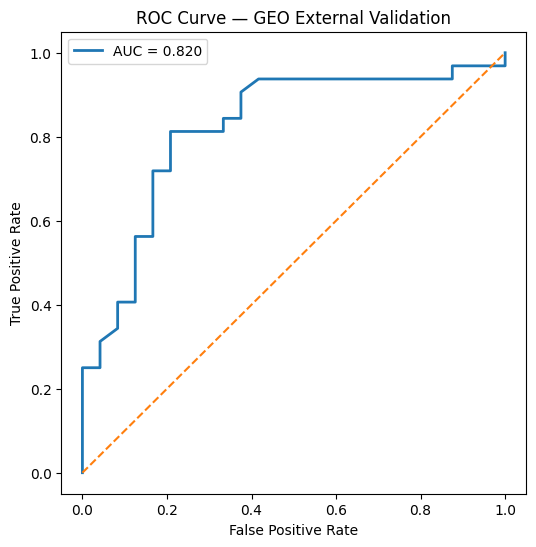

In [ ]:
# ============================================================
# Step 35: Plot ROC curve
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test_geo, y_prob_geo)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_geo:.3f}", linewidth=2)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — GEO External Validation")
plt.legend()

plt.show()

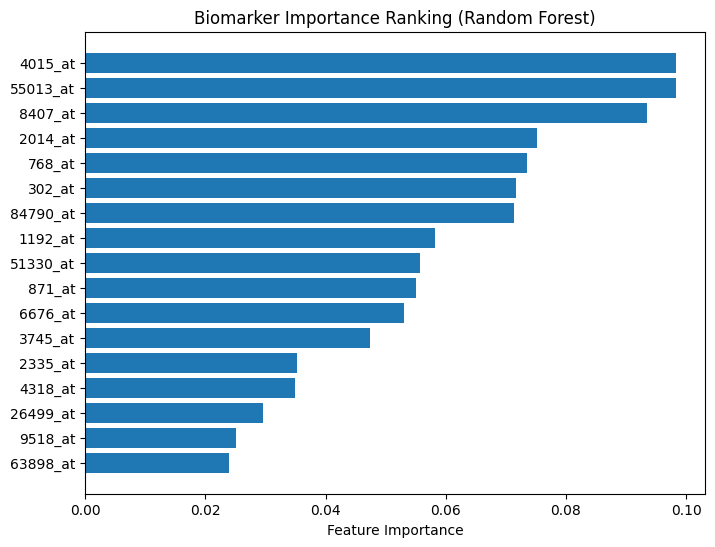

In [ ]:
# ============================================================
# Step 36: Feature importance plot
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "gene": X_geo.columns,
    "importance": rf_geo.feature_importances_
})

importance = importance.sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))

plt.barh(importance["gene"], importance["importance"])
plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.title("Biomarker Importance Ranking (Random Forest)")

plt.show()

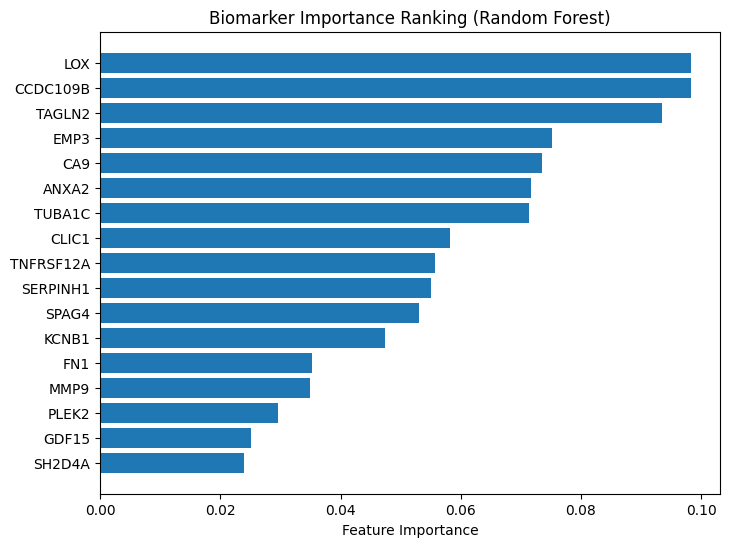

In [ ]:
# ============================================================
# Step 37: Replace probe IDs with gene symbols
# ============================================================

# Create probe → gene dictionary
probe_to_gene = dict(zip(
    geo_biomarker_probes["probe_id"],
    geo_biomarker_probes["gene_symbol"]
))

importance["gene"] = importance["gene"].map(probe_to_gene)

# Plot again
plt.figure(figsize=(8,6))

plt.barh(importance["gene"], importance["importance"])
plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.title("Biomarker Importance Ranking (Random Forest)")

plt.show()

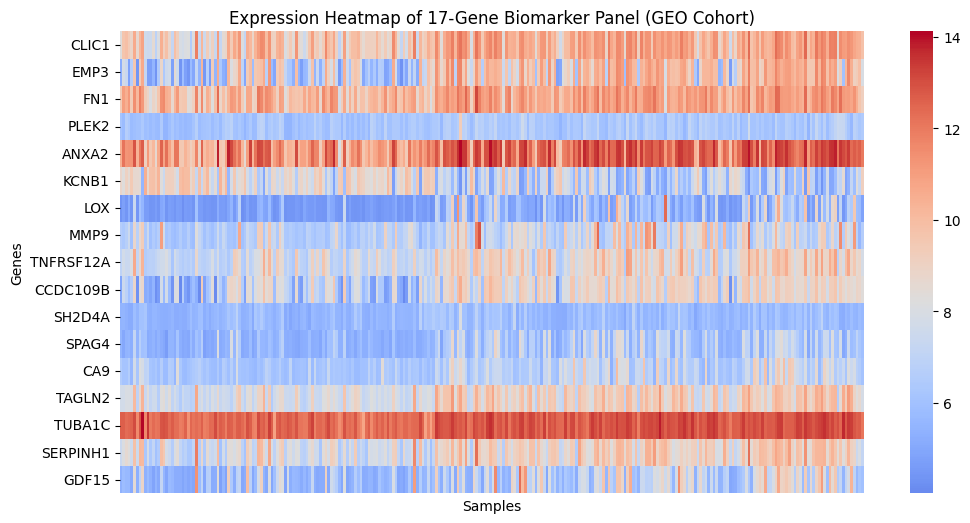

In [ ]:
# ============================================================
# Step 38: Heatmap of biomarker expression
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

# Copy feature matrix
heatmap_data = X_geo.copy()

# Rename probes → gene symbols
heatmap_data = heatmap_data.rename(columns=probe_to_gene)

# Order samples by tumor label
heatmap_data["tumor_label"] = y_geo
heatmap_data = heatmap_data.sort_values("tumor_label")

# Separate features again
heatmap_features = heatmap_data.drop(columns="tumor_label")

# Transpose to genes × samples
heatmap_matrix = heatmap_features.T

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_matrix,
    cmap="coolwarm",
    center=heatmap_matrix.mean().mean(),
    xticklabels=False
)

plt.title("Expression Heatmap of 17-Gene Biomarker Panel (GEO Cohort)")
plt.ylabel("Genes")
plt.xlabel("Samples")

plt.show()